# 07 · A transformer challenger: NILMFormer vs Seq2Point

**Requirement 3, extended.** Seq2Point is a 2018 convolutional design. Before standing behind it,
I tested it against the strongest recent transformer I could reproduce faithfully, under the
same data, homes, masks and metrics.

| | |
|---|---|
| **Input** | the same cleaned 1-minute corpus and split as notebooks 03–06; Seq2Point checkpoints `m2_seq2point_w81_s*` |
| **Output** | checkpoints `artifacts/models/m5_nilmformer_l129_s*`, `artifacts/tables/nb07_*.csv`, `artifacts/metrics/nb07_summary.json`, figures `nb07_*` |
| **Run time** | about 40 minutes on one laptop GPU |

**Why NILMFormer.** NILMFormer (Petralia et al., KDD 2025) was designed for the problem that hurts
this project most: household load is non-stationary, so a model trained on some homes sees
different load levels in others. It standardises every window and feeds the window's mean and
spread back as a separate token, so the output scale is relearned per window. It also gets the
time of day, day of week and month as inputs. It is the only transformer I found with openly licensed code
(Apache-2.0) and 1-minute REFIT washing-machine results in its own paper (BERT4NILM, for one, has
public code but no licence). Those results use different
homes and splits, so they are not comparable with mine. It is also small: about 0.38 M
parameters against 4.2 M for Seq2Point at an 81-minute window.

**Recipe.** I follow the published recipe and declare every deviation:

| | published | here |
|---|---|---|
| architecture | 3 encoder layers, d = 96, 8 heads, dilated-conv embedding, stats token | same (port in `src/refit_nilm/models/nilmformer.py`; outputs and gradients checked against the original code, `artifacts/metrics/nilmformer_port_check.json`) |
| window | 128 / 256 / 512 minutes (128 best in the paper) | 129 (odd, so a window has a centre minute) |
| inputs | load + sin/cos of minute, hour, day of week, month | same, in UK local time |
| scaling | load and target divided by the largest training load | same |
| training | Adam 1e-4, batch 64, ≤ 50 epochs, early stop 10, LR on plateau 5, MSE | same; masked MSE so unusable minutes (`Issues`, outages) carry no loss, as for Seq2Point |
| epochs | the training minutes tiled once, without overlap | the same number of windows, drawn at random positions |
| windows with gaps | discarded | kept if at most 10 % of the input minutes are missing (filled for the input only; unusable targets carry no loss), as for Seq2Point |
| inference | non-overlapping windows | each minute predicted by the window centred on it, exactly as Seq2Point is scored; the published tiling is checked in section 3 |

**Decision rule.** It has the form of the acceptance rule for the augmented model in notebook 05b,
with a stricter margin: the larger of the two models' seed standard deviations, where 05b used
Seq2Point's alone.
I wrote it after a 2-epoch timing check of the training code, and committed it (95895c9) after a
1-epoch end-to-end check of this notebook. Both checks were there only to catch code errors and
measure run time, and the rule did not change after them:

1. Single models, three seeds each (42, 10, 20), are compared on the validation home (House 18),
   on the minutes that both models can score.
2. The metrics are NDE and cycle F1, the two that selected the current model.
3. NILMFormer replaces Seq2Point only if its mean is better on **both** metrics by more than the
   larger of the two models' seed standard deviations. Otherwise Seq2Point stays: it is already
   validated, exported and served, and the challenger must clearly earn a change.
4. The test homes are then scored for both three-seed ensembles, whatever the decision, and
   nothing is changed after seeing them.

**Added after the first run, without changing the rule above.** The first run's NILMFormer seeds
scored worse than predicting zero on the validation home. I stopped it and checked the port first.
`scripts/check_nilmformer_port.py` loads the original repository's code at the pinned commit and
the port with identical weights; their outputs agree to within 10⁻⁷ and every gradient tensor to
within 4 × 10⁻⁶ of its own largest value (`artifacts/metrics/nilmformer_port_check.json`). I then added two sections that
use no test data. Section 4 diagnoses the failure: does the model fit its own training homes?
Section 5 is one declared exploratory run with a larger training budget, scored on validation
only. Neither can change the decision: a variant chosen after seeing results would need its own
pre-registered confirmation.

**Scoring history of the test homes.** Notebook 06 scored them first. This notebook has scored
them in two full runs: the first completed run (commit c54c8f8), whose numbers I read, and this
re-run with deterministic training, made to add the checks a review asked for. One-epoch code
checks before each full run also scored them. No choice depends on any of these scorings.


In [1]:
MAX_EPOCHS = 50  # the published budget; a quick end-to-end check of this notebook sets 1
MAX_EPOCHS_EXPLORE = 15  # section 5

In [2]:
import json
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from refit_nilm import config as C
from refit_nilm import datasets as D
from refit_nilm import metrics, plots
from refit_nilm import train as T
from refit_nilm import train_seq2seq as S

warnings.filterwarnings("ignore", category=FutureWarning)
plots.setup()
pd.set_option("display.width", 160, "display.max_columns", 30)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
W_S2P, W_NF = 81, 129
SEEDS = [42, 10, 20]
frames, corpora, stats = D.prepare([W_S2P, W_NF])
cp81, cp129, st81 = corpora[W_S2P], corpora[W_NF], stats[W_S2P]
SUMMARY: dict = {"window_seq2point": W_S2P, "window_nilmformer": W_NF, "seeds": SEEDS}
print({w: {k: len(v) for k, v in c.starts.items()} for w, c in corpora.items()})

{81: {'train': 3759548, 'seen_test': 871885, 'val': 553394, 'test': 3979448}, 129: {'train': 3756834, 'seen_test': 871023, 'val': 551963, 'test': 3979158}}


## 1. The two models side by side

Parameter counts and the scaling constant. The training split is identical for both: the same
homes and the same first 80 % of each, so only the window length and the model differ.

In [3]:
s2p = T.build("seq2point", W_S2P)
nf = S.build(S.Seq2SeqConfig())
n_s2p, n_nf = (sum(p.numel() for p in m.parameters()) for m in (s2p, nf))
scale = S.training_scale(cp129)
SUMMARY["parameters"] = {"seq2point": n_s2p, "nilmformer": n_nf}
SUMMARY["nilmformer_scale_w"] = scale
pd.DataFrame({"parameters": [n_s2p, n_nf], "window (min)": [W_S2P, W_NF], "output": ["centre minute", "every minute of the window"]},
             index=["Seq2Point", "NILMFormer"])

,parameters,window (min),output
Seq2Point,4186649,81,centre minute
NILMFormer,383283,129,every minute of the window


## 2. Training NILMFormer, three seeds

Each epoch draws as many random training windows as would tile the training minutes once (about
29,000 windows, 456 steps of 64). Early stopping watches validation NDE, as for Seq2Point.

In [4]:
histories = {}
for seed in SEEDS:
    cfg = S.Seq2SeqConfig(window=W_NF, seed=seed, max_epochs=MAX_EPOCHS)
    t0 = time.time()
    model, hist, sc = S.fit(cp129, cfg, device=DEVICE)
    S.save_run(C.MODEL_DIR / f"m5_nilmformer_l{W_NF}_s{seed}.pt", model, cfg, sc, hist)
    histories[seed] = hist
    best = min(hist, key=lambda h: h["val_nde"])
    print(f"seed {seed}: {len(hist)} epochs, best epoch {best['epoch']} (val NDE {best['val_nde']:.3f}), {time.time() - t0:.0f}s")
    del model
    torch.cuda.empty_cache()
SUMMARY["nilmformer_epochs"] = {str(s): {"epochs": len(h), "best_epoch": min(h, key=lambda r: r["val_nde"])["epoch"]} for s, h in histories.items()}

epoch  1  train_loss 0.00019  val_NDE 1.1399  (21s)


epoch  2  train_loss 0.00018  val_NDE 1.2947  (20s)


epoch  3  train_loss 0.00017  val_NDE 1.1928  (20s)


epoch  4  train_loss 0.00017  val_NDE 1.1520  (21s)


epoch  5  train_loss 0.00016  val_NDE 1.1662  (22s)


...

epoch  9  train_loss 0.00013  val_NDE 1.6963  (20s)


epoch 10  train_loss 0.00013  val_NDE 1.8690  (20s)


epoch 11  train_loss 0.00013  val_NDE 1.8158  (21s)


epoch 12  train_loss 0.00013  val_NDE 2.0188  (20s)


seed 20: 12 epochs, best epoch 2 (val NDE 1.140), 249s


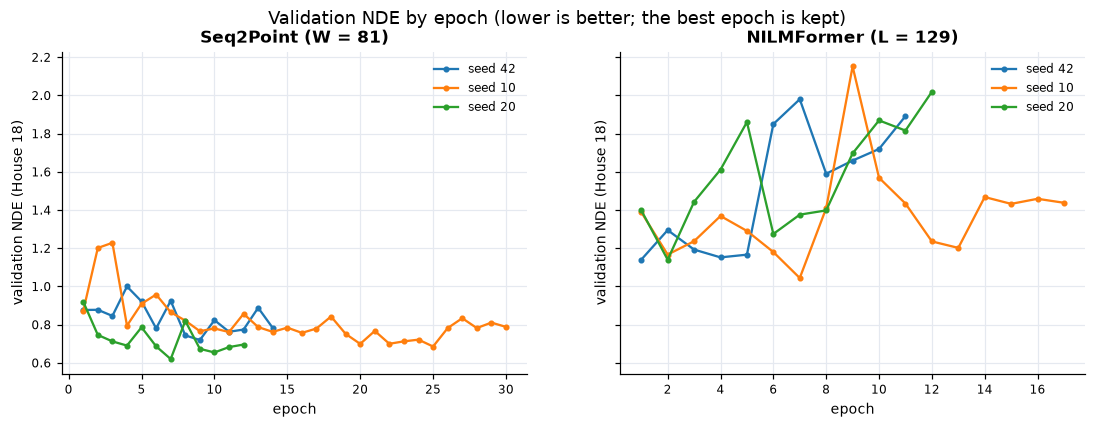

In [5]:
s2p_hist = {s: json.load(open(C.MODEL_DIR / f"m2_seq2point_w{W_S2P}_s{s}.json"))["history"] for s in SEEDS}
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
for ax, (name, hs) in zip(axes, [("Seq2Point (W = 81)", s2p_hist), ("NILMFormer (L = 129)", histories)]):
    for s, h in hs.items():
        ax.plot([r["epoch"] for r in h], [r["val_nde"] for r in h], marker="o", ms=3, label=f"seed {s}")
    ax.set(title=name, xlabel="epoch", ylabel="validation NDE (House 18)")
    ax.legend()
fig.suptitle("Validation NDE by epoch (lower is better; the best epoch is kept)")
plots.save(fig, "nb07_learning_curves")
plt.show()

## 3. Validation comparison (the decision)

Both models are scored with the project's metric code on House 18, restricted to the minutes both
can score. A minute can be valid for an 81-minute window but not for a 129-minute one near an
outage, and vice versa, so the shared set is slightly smaller than either. Seq2Point's numbers on
its own full set are in notebook 05.

In [6]:
S2P = {s: T.load_run(C.MODEL_DIR / f"m2_seq2point_w{W_S2P}_s{s}.pt", device=DEVICE)[0] for s in SEEDS}
NF = {s: S.load_run(C.MODEL_DIR / f"m5_nilmformer_l{W_NF}_s{s}.pt", device=DEVICE)[0] for s in SEEDS}
src81 = T.WindowSource(cp81, st81, DEVICE)
src129 = S.SeqWindowSource(cp129, scale, DEVICE)


def seq2point_power(cp, starts, seed):
    return T.predict(S2P[seed], src81, starts, st81)["power"]


def nilmformer_power(cp, starts, seed):
    return S.predict(NF[seed], src129, starts)


def series_for(split, house):
    # truth and per-seed predictions as minute series for one house, on the shared minutes
    st81, st129 = cp81.starts[split], cp129.starts[split]
    keep81 = cp81.house[st81 + W_S2P // 2] == house
    keep129 = cp129.house[st129 + W_NF // 2] == house
    st81, st129 = st81[keep81], st129[keep129]
    y = D.to_series(cp81, st81, cp81.wm[st81 + W_S2P // 2], house)
    preds = {}
    for s in SEEDS:
        preds[("Seq2Point", s)] = D.to_series(cp81, st81, seq2point_power(cp81, st81, s), house)
        preds[("NILMFormer", s)] = D.to_series(cp129, st129, nilmformer_power(cp129, st129, s), house)
    idx = y.index.union(preds[("NILMFormer", SEEDS[0])].index)
    y = y.reindex(idx)
    preds = {k: v.reindex(idx) for k, v in preds.items()}
    shared = y.notna() & preds[("Seq2Point", SEEDS[0])].notna() & preds[("NILMFormer", SEEDS[0])].notna()
    return y.where(shared), {k: v.where(shared) for k, v in preds.items()}


y_val, p_val = series_for("val", C.VAL_HOUSE)
SUMMARY["validation_shared_minutes"] = int(y_val.notna().sum())
rows = [{"model": m, "seed": s, **metrics.all_metrics(y_val, p)} for (m, s), p in p_val.items()]
val = pd.DataFrame(rows)
val.to_csv(C.TABLE_DIR / "nb07_validation_per_seed.csv", index=False)
cols = ["nde", "cycle_f1", "mae_w", "epd_wh", "f1", "sae", "overlap_pct", "extra_pct"]
agg = val.groupby("model")[cols].agg(["mean", "std"]).round(3)
print("shared validation minutes:", SUMMARY["validation_shared_minutes"])
agg

shared validation minutes: 551367


nde        cycle_f1          mae_w          epd_wh              f1          sae        overlap_pct        extra_pct         
             mean    std     mean    std    mean    std     mean      std   mean    std  mean    std        mean    std      mean      std
model                                                                                                                                     
NILMFormer  1.108  0.055    0.067  0.055  17.357  8.497  292.427  147.218  0.102  0.058  2.90  2.086      21.424  5.178   368.574  213.725
Seq2Point   0.675  0.051    0.603  0.016   5.296  0.548   83.813    9.026  0.426  0.033  0.59  0.091      61.286  2.568    97.719   11.602

In [7]:
m = val.groupby("model")[["nde", "cycle_f1"]].mean()
sd = val.groupby("model")[["nde", "cycle_f1"]].std()
margin = sd.max()  # the larger of the two models' seed SDs, per metric
better_nde = m.loc["NILMFormer", "nde"] < m.loc["Seq2Point", "nde"] - margin["nde"]
better_f1 = m.loc["NILMFormer", "cycle_f1"] > m.loc["Seq2Point", "cycle_f1"] + margin["cycle_f1"]
DECISION = "NILMFormer replaces Seq2Point" if (better_nde and better_f1) else "Seq2Point stays"
SUMMARY["validation"] = {
    "mean": m.round(4).to_dict(orient="index"), "sd": sd.round(4).to_dict(orient="index"),
    "margin": margin.round(4).to_dict(), "nilmformer_better_nde": bool(better_nde), "nilmformer_better_cycle_f1": bool(better_f1),
    "decision": DECISION,
}
print(f"NDE        Seq2Point {m.loc['Seq2Point','nde']:.3f}  NILMFormer {m.loc['NILMFormer','nde']:.3f}  margin {margin['nde']:.3f}  -> NILMFormer clearly better: {better_nde}")
print(f"cycle F1   Seq2Point {m.loc['Seq2Point','cycle_f1']:.3f}  NILMFormer {m.loc['NILMFormer','cycle_f1']:.3f}  margin {margin['cycle_f1']:.3f}  -> NILMFormer clearly better: {better_f1}")
print("DECISION:", DECISION)

NDE        Seq2Point 0.675  NILMFormer 1.108  margin 0.055  -> NILMFormer clearly better: False
cycle F1   Seq2Point 0.603  NILMFormer 0.067  margin 0.055  -> NILMFormer clearly better: False
DECISION: Seq2Point stays


In [8]:
# secondary view: three-seed ensembles (mean power), the form the service uses
ens_val = {name: pd.concat([p_val[(name, s)] for s in SEEDS], axis=1).mean(axis=1, skipna=False) for name in ("Seq2Point", "NILMFormer")}
ens_val_tab = pd.DataFrame({name: metrics.all_metrics(y_val, p) for name, p in ens_val.items()}).T[cols].round(3)
SUMMARY["validation_ensemble"] = ens_val_tab.to_dict(orient="index")
ens_val_tab

,nde,cycle_f1,mae_w,epd_wh,f1,sae,overlap_pct,extra_pct
Seq2Point,0.602,0.644,5.202,80.747,0.429,0.59,62.50,96.505
NILMFormer,1.061,0.064,17.333,277.193,0.094,2.90,21.73,368.268


### Is the ranking stable under other cycle definitions?

Cycle F1 matches washes at temporal overlap (IoU) ≥ 0.5, a convention. I recompute it, per seed,
at IoU thresholds from 0.1 to 0.9 and with a start-time tolerance of 5–60 minutes instead. The
comparison above holds only if Seq2Point stays ahead under every one of them.

In [9]:
from refit_nilm import cycles
from refit_nilm import uncertainty as U

DEFINITIONS = [("IoU", round(t, 1)) for t in np.arange(0.1, 0.95, 0.1)] + [("start ± min", t) for t in (5, 10, 15, 30, 60)]
tc_val = cycles.detect_cycles(y_val)
rank_rows = []
for (name, s), p in p_val.items():
    pc = cycles.detect_cycles(p.where(y_val.notna()))
    for kind, thr in DEFINITIONS:
        n_m = len(metrics.match_cycles(tc_val, pc, iou_min=thr)) if kind == "IoU" else U.match_by_start(tc_val, pc, thr)
        rank_rows.append({"model": name, "seed": s, "kind": kind, "threshold": thr, "f1": U.f1_from_counts(len(tc_val), len(pc), n_m)})
rank = pd.DataFrame(rank_rows).groupby(["kind", "threshold", "model"])["f1"].mean().unstack("model")
rank["Seq2Point ahead"] = rank["Seq2Point"] > rank["NILMFormer"]
rank.to_csv(C.TABLE_DIR / "nb07_cycle_definition_ranking_val.csv")
SUMMARY["cycle_definition_ranking_val"] = {"seq2point_ahead_under_all": bool(rank["Seq2Point ahead"].all()),
                                           "definitions": len(rank)}
print("Seq2Point ahead under every definition:", bool(rank["Seq2Point ahead"].all()))
rank.round(3)

Seq2Point ahead under every definition: True


model                  NILMFormer  Seq2Point  Seq2Point ahead
kind        threshold                                        
IoU         0.1             0.083      0.633             True
            0.2             0.081      0.633             True
            0.3             0.075      0.633             True
            0.4             0.071      0.624             True
            0.5             0.067      0.603             True
            0.6             0.062      0.554             True
            0.7             0.049      0.483             True
            0.8             0.040      0.408             True
            0.9             0.022      0.239             True
start ± min 5.0             0.063      0.466             True
            10.0            0.067      0.591             True
            15.0            0.071      0.591             True
            30.0            0.077      0.633             True
            60.0            0.085      0.633             True

### Does my inference choice handicap NILMFormer?

The paper predicts with non-overlapping windows; I predict every minute from the window centred on
it. To check that this deviation is not what made NILMFormer lose, I also score its three seeds on
the validation home with the published tiling, on the same minutes.

In [10]:
def tiled_power(model, house: int) -> pd.Series:
    # non-overlapping 129-minute windows across the home's contiguous record, every minute predicted once
    pos = np.flatnonzero((cp129.split == "val") & (cp129.house == house))
    starts = np.arange(pos[0], pos[-1] - W_NF + 2, W_NF)
    out = np.full(len(cp129.agg), np.nan)
    model.eval()
    with torch.no_grad():
        for i in range(0, len(starts), 512):
            chunk = starts[i : i + 512]
            xb, _, _ = src129.batch(torch.as_tensor(chunk, device=DEVICE))
            pw = (model(xb)["power"].clamp_min(0) * src129.scale).cpu().numpy()
            for k, s0 in enumerate(chunk):
                out[s0 : s0 + W_NF] = pw[k]
    return pd.Series(out[pos], index=pd.to_datetime(cp129.time[pos], unit="s", utc=True))


mode_rows = []
for s in SEEDS:
    tiled = tiled_power(NF[s], C.VAL_HOUSE).reindex(y_val.index).where(y_val.notna())
    for mode, p in (("centred (used here)", p_val[("NILMFormer", s)]), ("tiled (published)", tiled)):
        mode_rows.append({"inference": mode, "seed": s, **{k: metrics.all_metrics(y_val, p)[k] for k in ("nde", "cycle_f1")}})
modes = pd.DataFrame(mode_rows)
modes.to_csv(C.TABLE_DIR / "nb07_inference_mode_val.csv", index=False)
mode_stats = modes.groupby("inference")[["nde", "cycle_f1"]].agg(["mean", "std"])
SUMMARY["inference_mode_val"] = {mode: {f"{metric}_{stat}": round(float(v), 4) for (metric, stat), v in row.items()}
                                 for mode, row in mode_stats.iterrows()}
modes.groupby("inference")[["nde", "cycle_f1"]].agg(["mean", "std"]).round(3)

nde        cycle_f1       
                      mean    std     mean    std
inference                                        
centred (used here)  1.108  0.055    0.067  0.055
tiled (published)    1.138  0.014    0.074  0.046

## 4. Diagnosis: does NILMFormer fit its own training homes?

A model can fail on a new home for two different reasons. It may learn the training homes but not
transfer (a generalisation problem), or it may not learn them at all (an optimisation problem).
The NDE on a 5 % sample of training windows, on the later 20 % of the training homes (seen) and
on the validation home separates the two. I also count optimiser steps, because the published
recipe sizes an epoch by tiling the data once with batches of 64.

In [11]:
rng = np.random.default_rng(0)
diag = []
for split in ("train", "seen_test", "val"):
    a, b = cp81.starts[split], cp129.starts[split]
    if split == "train":
        a = np.sort(rng.choice(a, len(a) // 20, replace=False))
        b = np.sort(rng.choice(b, len(b) // 20, replace=False))
    for s in SEEDS:
        diag.append({"split": split, "model": "Seq2Point", "seed": s, "nde": metrics.nde(cp81.wm[a + W_S2P // 2], seq2point_power(cp81, a, s))})
        diag.append({"split": split, "model": "NILMFormer", "seed": s, "nde": metrics.nde(cp129.wm[b + W_NF // 2], nilmformer_power(cp129, b, s))})
diag = pd.DataFrame(diag)
fit_tab = diag.groupby(["model", "split"])["nde"].agg(["mean", "std"]).round(3).unstack()
steps_s2p = {s: len(h) * int(np.ceil(len(cp81.starts["train"]) / 1000)) for s, h in s2p_hist.items()}
steps_nf = {s: len(h) * int(np.ceil(np.ceil(len(cp129.starts["train"]) / W_NF) / 64)) for s, h in histories.items()}
SUMMARY["fit_diagnosis_nde_mean"] = diag.groupby(["model", "split"])["nde"].mean().round(3).unstack().to_dict(orient="index")
SUMMARY["optimiser_steps"] = {"seq2point": steps_s2p, "nilmformer": steps_nf}
print("optimiser steps run (including the epochs after the best one):")
print("  Seq2Point :", steps_s2p)
print("  NILMFormer:", steps_nf)
fit_tab

optimiser steps run (including the epochs after the best one):
  Seq2Point : {42: 52640, 10: 112800, 20: 45120}
  NILMFormer: {42: 5016, 10: 7752, 20: 5472}


mean                     std              
split      seen_test  train    val seen_test  train    val
model                                                     
NILMFormer     0.826  0.830  1.108     0.070  0.065  0.055
Seq2Point      0.623  0.259  0.675     0.016  0.061  0.051

## 5. Exploratory: the same model with Seq2Point's training budget

One declared change, chosen because section 4 points to under-training. Each epoch draws 8× as
many windows, which gives roughly the optimiser steps Seq2Point received (about 3,600 per epoch, at
most 15 epochs). Everything else is as published. One seed, scored on validation only.

In [12]:
EXPL_FACTOR = 8
cfg_x = S.Seq2SeqConfig(window=W_NF, seed=42, max_epochs=MAX_EPOCHS_EXPLORE, windows_per_epoch_factor=EXPL_FACTOR)
model_x, hist_x, _ = S.fit(cp129, cfg_x, device=DEVICE)
S.save_run(C.MODEL_DIR / f"m5x_nilmformer_l{W_NF}_x{EXPL_FACTOR}_s42.pt", model_x, cfg_x, scale, hist_x)
st129v = cp129.starts["val"]
px = D.to_series(cp129, st129v, S.predict(model_x, src129, st129v), C.VAL_HOUSE).reindex(y_val.index).where(y_val.notna())
rows_x = [
    {"model": "Seq2Point (mean of 3 seeds)", **val[val.model == "Seq2Point"][cols].mean().to_dict()},
    {"model": "NILMFormer, published budget (mean of 3 seeds)", **val[val.model == "NILMFormer"][cols].mean().to_dict()},
    {"model": f"NILMFormer, {EXPL_FACTOR}x windows per epoch (seed 42)", **{k: metrics.all_metrics(y_val, px)[k] for k in cols}},
]
b_tr = np.sort(np.random.default_rng(0).choice(cp129.starts["train"], len(cp129.starts["train"]) // 20, replace=False))
b_seen = cp129.starts["seen_test"]
fit_x = {"train": metrics.nde(cp129.wm[b_tr + W_NF // 2], S.predict(model_x, src129, b_tr)),
         "seen_test": metrics.nde(cp129.wm[b_seen + W_NF // 2], S.predict(model_x, src129, b_seen))}
best_x = min(hist_x, key=lambda h: h["val_nde"])
SUMMARY["exploratory"] = {"factor": EXPL_FACTOR, "epochs": len(hist_x), "best_epoch": best_x["epoch"],
                          "validation": {k: round(float(v), 4) for k, v in rows_x[2].items() if k != "model"},
                          "fit_nde": {k: round(v, 3) for k, v in fit_x.items()}}
print(f"exploratory run: {len(hist_x)} epochs, best epoch {best_x['epoch']}; NDE train sample {fit_x['train']:.3f}, seen homes {fit_x['seen_test']:.3f}")
pd.DataFrame(rows_x).set_index("model").round(3)

epoch  1  train_loss 0.00017  val_NDE 1.4733  (57s)


epoch  2  train_loss 0.00014  val_NDE 1.1509  (56s)


epoch  3  train_loss 0.00012  val_NDE 2.1003  (56s)


epoch  4  train_loss 0.00011  val_NDE 1.5142  (55s)


epoch  5  train_loss 0.00010  val_NDE 1.5933  (57s)


...

epoch 10  train_loss 0.00007  val_NDE 1.2144  (55s)


epoch 11  train_loss 0.00007  val_NDE 1.3037  (55s)


epoch 12  train_loss 0.00007  val_NDE 1.2332  (55s)


exploratory run: 12 epochs, best epoch 2; NDE train sample 0.783, seen homes 0.786


,nde,cycle_f1,mae_w,epd_wh,f1,sae,overlap_pct,extra_pct
model,,,,,,,,
Seq2Point (mean of 3 seeds),0.675,0.603,5.296,83.813,0.426,0.59,61.286,97.719
"NILMFormer, published budget (mean of 3 seeds)",1.108,0.067,17.357,292.427,0.102,2.90,21.424,368.574
"NILMFormer, 8x windows per epoch (seed 42)",1.151,0.132,23.886,414.388,0.058,4.63,23.791,539.165


## 6. Unseen test homes, scored after the decision

Both three-seed ensembles on House 8 (the reference REFIT test home) and the five other unseen
homes, on the minutes both can score, for the pre-registered models only. These homes played no
part in any choice above, and the exploratory model of section 5 is not scored on them.

In [13]:
test_rows, test_series = [], {}
for h in [C.TEST_HOUSE] + C.EXTRA_UNSEEN_HOUSES:
    y_h, p_h = series_for("test", h)
    for name in ("Seq2Point", "NILMFormer"):
        ens = pd.concat([p_h[(name, s)] for s in SEEDS], axis=1).mean(axis=1, skipna=False)
        test_rows.append({"house": h, "model": name, **metrics.all_metrics(y_h, ens)})
        if h == C.TEST_HOUSE:
            test_series[name] = ens
    if h == C.TEST_HOUSE:
        test_series["truth"] = y_h
test = pd.DataFrame(test_rows)
test.to_csv(C.TABLE_DIR / "nb07_unseen_ensembles.csv", index=False)
h8 = test[test.house == C.TEST_HOUSE].set_index("model")[cols].round(3)
mean6 = test.groupby("model")[cols].mean().round(3)
SUMMARY["house8"] = h8.to_dict(orient="index")
SUMMARY["unseen_mean"] = mean6.to_dict(orient="index")
SUMMARY["unseen_cycle_f1_per_home"] = test.pivot(index="house", columns="model", values="cycle_f1").round(3).to_dict()
print("House 8"); display(h8)
print("Mean over six unseen homes"); display(mean6)
test.pivot(index="house", columns="model", values=["nde", "cycle_f1"]).round(3)

House 8


,nde,cycle_f1,mae_w,epd_wh,f1,sae,overlap_pct,extra_pct
model,,,,,,,,
Seq2Point,0.736,0.566,23.567,339.709,0.493,0.283,37.998,33.691
NILMFormer,0.905,0.170,41.149,466.082,0.184,0.011,17.015,84.094


Mean over six unseen homes


,nde,cycle_f1,mae_w,epd_wh,f1,sae,overlap_pct,extra_pct
model,,,,,,,,
NILMFormer,0.919,0.114,21.281,256.560,0.213,0.500,18.796,119.647
Seq2Point,0.826,0.482,13.096,182.213,0.507,0.312,42.330,59.295


nde             cycle_f1          
model NILMFormer Seq2Point NILMFormer Seq2Point
house                                          
1          0.956     0.860      0.059     0.169
6          0.701     0.415      0.211     0.523
8          0.905     0.736      0.170     0.566
10         0.808     0.712      0.163     0.646
19         1.243     1.405      0.008     0.736
20         0.900     0.826      0.071     0.253

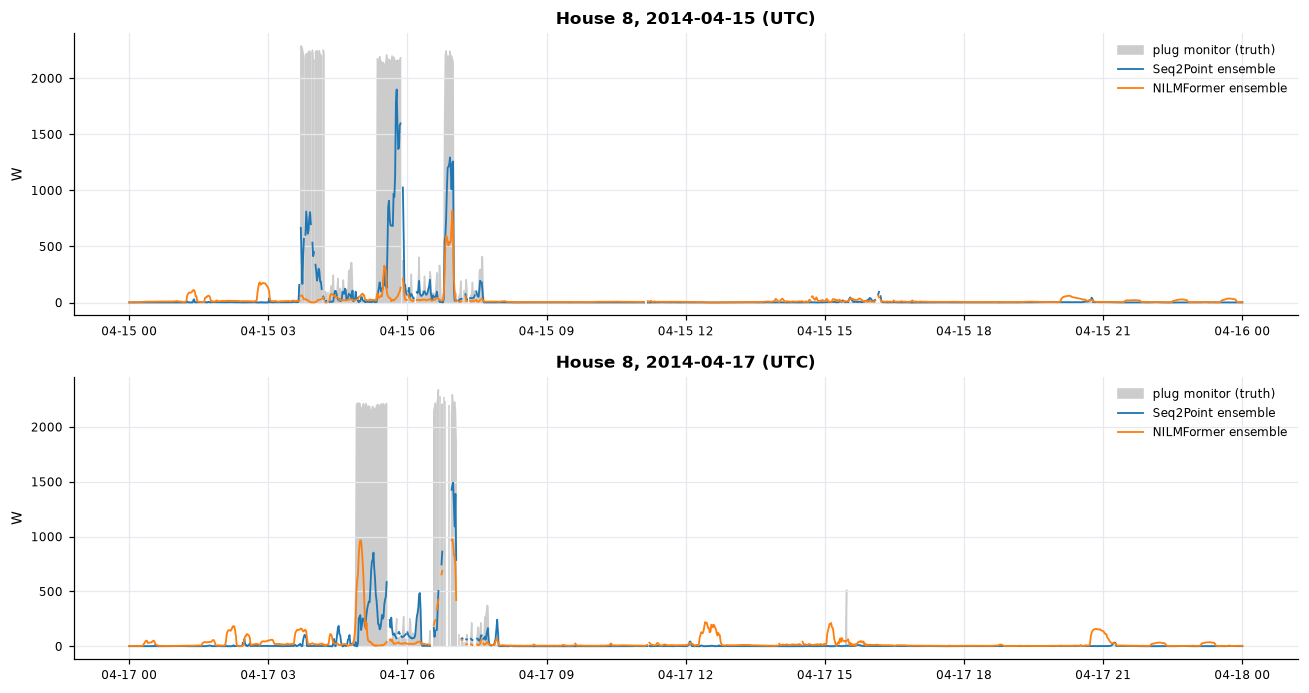

In [14]:
days = json.load(open(C.METRIC_DIR / "nb06_summary.json"))["plot_days"]
fig, axes = plt.subplots(len(days), 1, figsize=(12, 3.2 * len(days)))
for ax, day in zip(np.atleast_1d(axes), days):
    sl = slice(pd.Timestamp(day, tz="UTC"), pd.Timestamp(day, tz="UTC") + pd.Timedelta("1D"))
    ax.fill_between(test_series["truth"][sl].index, test_series["truth"][sl], color="0.8", label="plug monitor (truth)")
    ax.plot(test_series["Seq2Point"][sl], lw=1.2, label="Seq2Point ensemble")
    ax.plot(test_series["NILMFormer"][sl], lw=1.2, label="NILMFormer ensemble")
    ax.set(title=f"House 8, {day} (UTC)", ylabel="W")
    ax.legend(loc="upper right")
fig.tight_layout()
plots.save(fig, "nb07_house8_days")
plt.show()

## 7. Cost to serve

CPU time to process one day of 1-minute data with one model: single thread, fp32, PyTorch eager
mode, the median of five repeats. Seq2Point needs one 81-minute window per minute. NILMFormer
needs either one 129-minute window per minute (centred, as scored here) or 12 non-overlapping
windows per day (tiled, as published). This is a like-for-like proxy, not the service's cost: the
service runs the three-model Seq2Point ensemble as int8 ONNX.

In [15]:
torch.set_num_threads(1)
REPEATS = 5


def time_model(model, x: torch.Tensor, batch: int = 256) -> list[float]:
    runs = []
    with torch.no_grad():
        model(x[:16])  # warm-up
        for _ in range(REPEATS):
            t0 = time.perf_counter()
            for i in range(0, len(x), batch):
                model(x[i : i + batch])
            runs.append(time.perf_counter() - t0)
    return runs


g = torch.Generator().manual_seed(0)
s2p_cpu = T.load_run(C.MODEL_DIR / f"m2_seq2point_w{W_S2P}_s42.pt", device="cpu")[0]
nf_cpu = S.load_run(C.MODEL_DIR / f"m5_nilmformer_l{W_NF}_s42.pt", device="cpu")[0]
runs = {
    "Seq2Point (1,440 windows of 81)": time_model(s2p_cpu, torch.randn(1440, W_S2P, generator=g)),
    "NILMFormer, centred (1,440 windows of 129)": time_model(nf_cpu, torch.randn(1440, 9, W_NF, generator=g)),
    "NILMFormer, tiled (12 windows of 129)": time_model(nf_cpu, torch.randn(int(np.ceil(1440 / W_NF)), 9, W_NF, generator=g)),
}
cost = pd.DataFrame({k: {"median_s": np.median(v), "min_s": min(v), "max_s": max(v)} for k, v in runs.items()}).T
SUMMARY["cpu_seconds_per_day_single_model"] = {k: round(float(v), 4) for k, v in cost["median_s"].items()}
SUMMARY["cpu_ratio_centred_nilmformer_to_seq2point"] = round(float(cost["median_s"].iloc[1] / cost["median_s"].iloc[0]), 1)
cost.round(4)

,median_s,min_s,max_s
"Seq2Point (1,440 windows of 81)",0.2829,0.2731,0.2894
"NILMFormer, centred (1,440 windows of 129)",3.8869,3.6184,3.9596
"NILMFormer, tiled (12 windows of 129)",0.0199,0.0198,0.0201


In [16]:
(C.METRIC_DIR / "nb07_summary.json").write_text(json.dumps(SUMMARY, indent=2, default=float))
print(json.dumps(SUMMARY["validation"], indent=1))

{
 "mean": {
  "NILMFormer": {
   "nde": 1.1078,
   "cycle_f1": 0.0675
  },
  "Seq2Point": {
   "nde": 0.6746,
   "cycle_f1": 0.6034
  }
 },
 "sd": {
  "NILMFormer": {
   "nde": 0.0552,
   "cycle_f1": 0.0552
  },
  "Seq2Point": {
   "nde": 0.0505,
   "cycle_f1": 0.0159
  }
 },
 "margin": {
  "nde": 0.0552,
  "cycle_f1": 0.0552
 },
 "nilmformer_better_nde": false,
 "nilmformer_better_cycle_f1": false,
 "decision": "Seq2Point stays"
}


## Summary

**Decision, by the rule stated in the header: Seq2Point stays.**

| validation home (House 18), shared minutes, mean ± sd of 3 seeds | NDE | cycle F1 | false energy (% of true) |
|---|---|---|---|
| Seq2Point | **0.675 ± 0.051** | **0.603 ± 0.016** | 98 % |
| NILMFormer, published recipe with the declared deviations | 1.108 ± 0.055 | 0.067 ± 0.055 | 369 % |

NILMFormer is worse on both metrics, by far more than the 0.055 margin. Notebook 05b's margin
(Seq2Point's spread alone) gives the same decision. On this home it is also worse than predicting
zero. The three-seed ensembles agree: NDE 0.60 vs 1.06, cycle F1 0.64 vs 0.06.

**The result survives the two obvious objections.**
* *Cycle definition.* Seq2Point leads under all 14 cycle definitions, at IoU 0.1 to 0.9 and with
  start tolerances of 5 to 60 minutes.
* *My inference deviation.* With the published non-overlapping tiling, NILMFormer scores NDE 1.138
  ± 0.014 and cycle F1 0.074 ± 0.046, against 1.108 and 0.067 with my centred windows. That
  deviation did not handicap it.

**Why it loses, as far as the measurements go.**
1. *It is under-trained under the published budget.* It ran 5,016–7,752 optimiser steps before
   early stopping, against 45,120–112,800 for Seq2Point. Its NDE on its own training homes is 0.83,
   against 0.26 for Seq2Point.
2. *A larger budget does not rescue it on a new home.* With 8× the windows per epoch (section 5),
   the training loss keeps falling, from 0.00017 to 0.00007 over 12 epochs. Validation NDE never gets
   below 1.15, which it reached at epoch 2. The kept epoch-2 weights fit the training homes only
   slightly better than the published budget did (NDE 0.78 vs 0.83). The later, better-fitting
   weights were not scored on the training homes.

   So I can say that more training lowers the training loss without helping the validation home. I
   cannot say how well the longest-trained weights fit the training homes. A plausible mechanism,
   which I have not tested: per-window normalisation discards the absolute power level, one of the
   few cues that separate a washing machine's 2 kW heater from other 2 kW loads in an unseen home.

**Unseen test homes, scored after the decision** (three-seed ensembles, shared minutes):

| | House 8 NDE | House 8 cycle F1 | six-home mean NDE | six-home mean cycle F1 |
|---|---|---|---|---|
| Seq2Point | **0.736** | **0.566** | **0.826** | **0.482** |
| NILMFormer | 0.905 | 0.170 | 0.919 | 0.114 |

On five of the six unseen homes NILMFormer does better than predicting zero. On House 19 it does not
(NDE 1.24), and neither does Seq2Point (1.41); that is the one home where NILMFormer has the lower
NDE. It is worse than Seq2Point on cycle F1 in all six homes. Its small total-energy error on House 8
(SAE 0.01) is a cancellation: it recovers only 17 % of the true energy and adds 84 % in ghost power.

**Cost** (one model, one CPU thread, fp32 PyTorch, median of five repeats, per day of data). These
are a like-for-like proxy, not the service's cost.

| model and inference mode | CPU time per day of data |
|---|---|
| Seq2Point | 0.28 s |
| NILMFormer, centred windows | 3.89 s (about 14× Seq2Point) |
| NILMFormer, published tiling | 0.02 s, cheaper than Seq2Point, with about the same accuracy as centred |

Cost is therefore not a reason against NILMFormer. Accuracy is.

**What this shows, and what it does not.** With this split, seven training homes and the published
recipe, NILMFormer transfers to new homes worse than Seq2Point, and a larger training budget does not
change that on the validation home. It does not show that transformers cannot work here. The
comparison is worth repeating with more training homes, cross-validation over homes for early
stopping, and a tuning budget matched to Seq2Point's (the v2 plan).

## Verification log

* The decision rule was committed (95895c9) before the first full training run. Before that, a
  2-epoch timing check and a 1-epoch end-to-end check had run, only to catch code errors. The rule
  did not change after them.
* The first full run was stopped during its third seed, once validation NDE stayed above 1. Before
  changing anything else I checked the port against the original repository's code
  (`artifacts/metrics/nilmformer_port_check.json`). Outputs agree to within 6 × 10⁻⁸, the training
  mode (with dropout active) to 3 × 10⁻⁹, and every gradient tensor to within 4 × 10⁻⁶ of its own largest value.
* Training now runs with PyTorch's deterministic algorithms. Retraining seed 42 in a fresh process
  reproduces this notebook's checkpoint and its 11-epoch validation curve bit for bit
  (`artifacts/metrics/seq2seq_determinism_check.json`). Against the earlier, non-deterministic run
  (commit c54c8f8), the decision metrics agree to three decimals (validation NDE 1.1077 vs
  1.1078). Other figures moved in the third decimal, for example the exploratory run's cycle F1,
  0.131 vs 0.132.
* Seq2Point's numbers on the shared minutes reproduce notebook 05 (validation NDE 0.675 ± 0.051 vs
  0.68 ± 0.05) and notebook 06 (House 8 NDE 0.736 vs 0.737 on its own minute set). The comparison
  harness is therefore consistent with the earlier notebooks.
* One-epoch end-to-end checks of this notebook, run to catch errors before each full run, also
  scored the test homes. No decision depends on those numbers or on the ones above.
* Visual: on House 8 the NILMFormer ensemble catches parts of the heating blocks, at lower amplitude
  than Seq2Point, and adds 100–250 W bumps at other times of day. That matches its 84 % false energy.